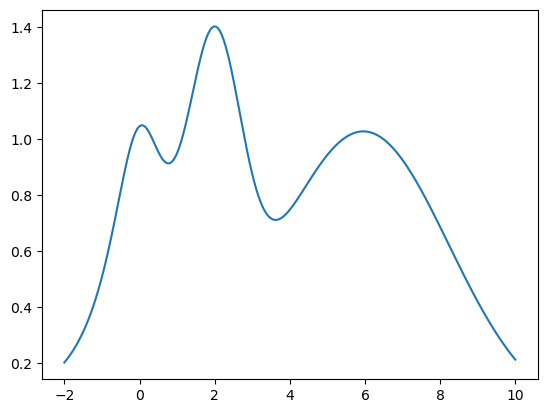

In [ ]:
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import gridspec


def target(x):
    # evaluate the object function
    # its max is at x=2
    return np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2 + 1)

x = np.linspace(-2, 10, 10000).reshape(-1, 1)
y = target(x)

plt.plot(x, y)

## 创建贝叶斯优化目标
采集函数为UCB  参数$\kappa=5$


In [3]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=5.)
optimizer = BayesianOptimization(target, {'x': (-2, 10)}, acquisition_function=acquisition_function, random_state=27)
optimizer.maximize(init_points=2, n_iter=20)


|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.8354486 | -0.471610 |
| 6         | 0.9452193 | 0.9845817 |
| 7         | 0.2117975 | 10.0      |
| 8         | 1.0098042 | 5.5297953 |
| 9         | 0.2016616 | -2.0      |
| 10        | 0.8308491 | 4.4210046 |
| 11        | 0.9893538 | 6.5811838 |
| 12        | 1.3997418 | 2.0506998 |
| 13        | 0.4779734 | 8.7666595 |
| 14        | 1.2507996 | 2.4377140 |
| 15        | 1.3185496 | 1.6790895 |
| 16        | 1.3948065 | 1.9100859 |
| 17        | 1.4018132 | 1.9910397 |
| 18        | 1.4018890 | 1.9978038 |
| 19        | 1.4018935 | 1.9988421 |
| 20        | 1.4018953 | 1.9994203 |
| 21        | 1.4018962 | 1.9998367 |
| 22        | 1.4018967 | 2.0001782 |


In [4]:
def posterior(optimizer, grid):
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y):
    fig = plt.figure(figsize=(7, 5))
    steps = len(optimizer.space)
    fig.suptitle(
        'Gaussian Process and Utility Function After {} Steps'.format(steps),
        fontsize=30
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label='Target')
    axis.plot(x_obs.flatten(), y_obs, 'D', markersize=8, label=u'Observations', color='r')
    axis.plot(x, mu, '--', color='k', label='Prediction')

    axis.fill(np.concatenate([x, x[::-1]]),
              np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=.6, fc='c', ec='None', label='95% confidence interval')

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel('f(x)', fontdict={'size':20})
    axis.set_xlabel('x', fontdict={'size':20})


    utility_function = acquisition.UpperConfidenceBound(kappa=5)
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x = x.flatten()

    acq.plot(x, utility, label='Utility Function', color='purple')
    acq.plot(x[np.argmax(utility)], np.max(utility), '*', markersize=15,
             label=u'Next Best Guess', markerfacecolor='gold', markeredgecolor='k', markeredgewidth=1)
    acq.set_xlim((-2, 10))
    #acq.set_ylim((0, np.max(utility) + 0.5))
    acq.set_ylabel('Utility', fontdict={'size':20})
    acq.set_xlabel('x', fontdict={'size':20})
    

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.)

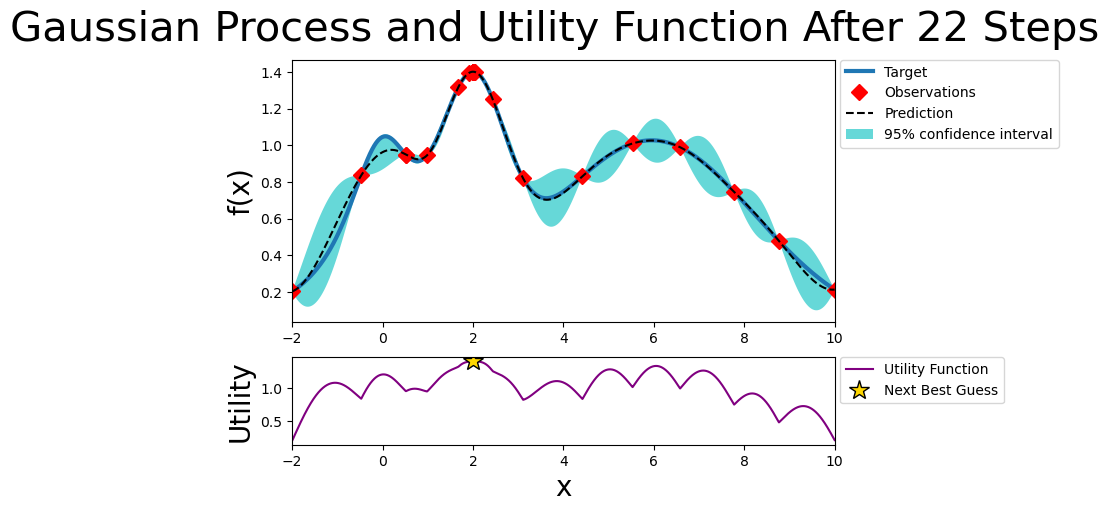

In [5]:
plot_gp(optimizer, x, y)

|   iter    |  target   |     x     |
-------------------------------------
| 23        | 1.4018970 | 2.0004937 |


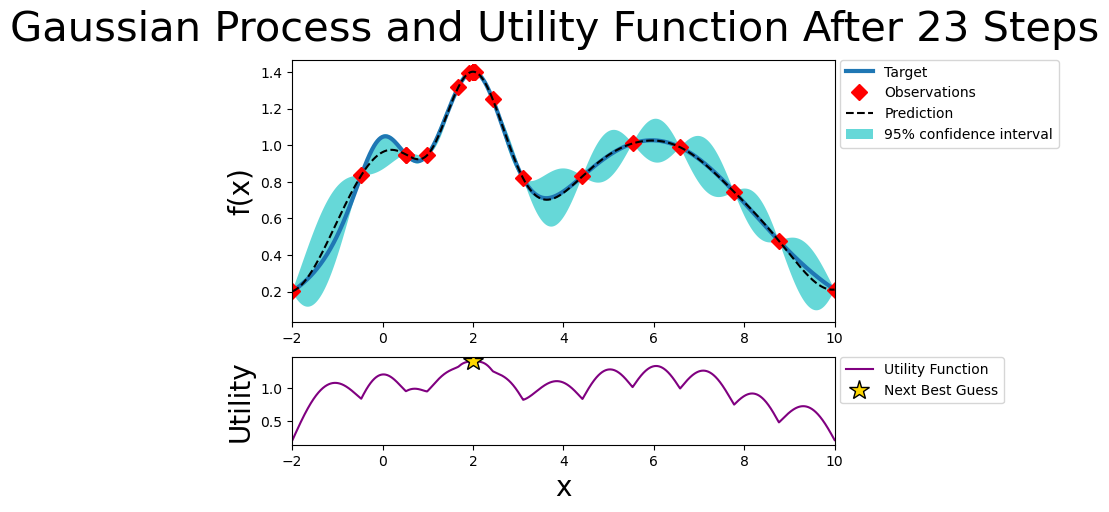

In [6]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)

|   iter    |  target   |     x     |
-------------------------------------
| 24        | 1.4018971 | 2.0008242 |


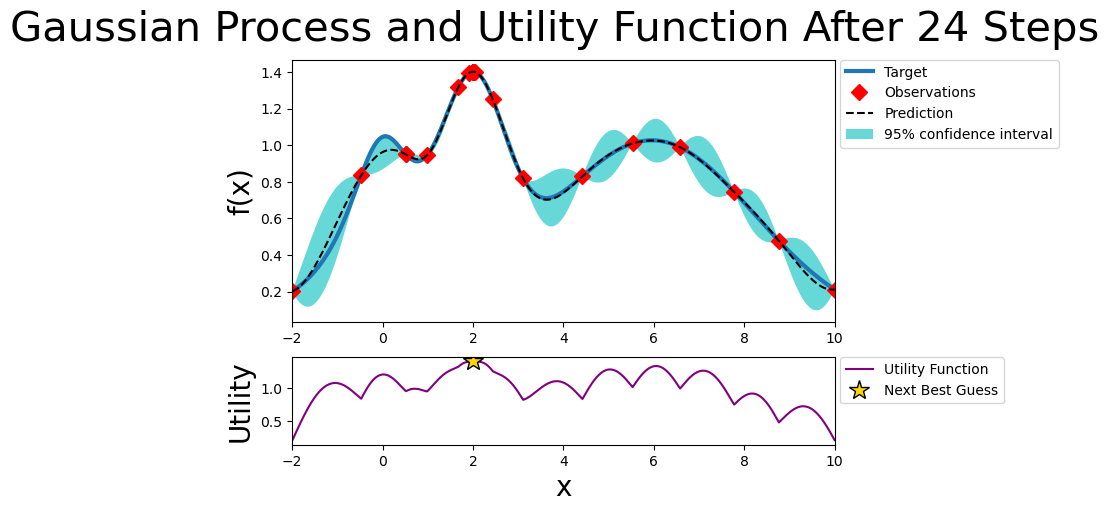

In [7]:
optimizer.maximize(init_points=0, n_iter=1)
plot_gp(optimizer, x, y)